In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso, SGDRegressor
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import pickle
import warnings
warnings.filterwarnings('ignore')

In [42]:
#youtube_df = pd.read_csv('D:/Projects/Content_Monetization_Modeler/data/youtube_ad_revenue_dataset.csv')
url = "https://github.com/vinodg-dotcom/Content_Monetization_Modeler/blob/main/youtube_ad_revenue_dataset.csv?raw=true"
youtube_df = pd.read_csv(url)

In [43]:
youtube_df.head()

,video_id,date,views,likes,comments,watch_time_minutes,video_length_minutes,subscribers,category,device,country,ad_revenue_usd
0,vid_3092,2024-09-24 10:50:40.993199,9936,1221.0,320.0,26497.214184,2.862137,228086,Entertainment,TV,IN,203.178237
1,vid_3459,2024-09-22 10:50:40.993199,10017,642.0,346.0,15209.747445,23.738069,736015,Gaming,Tablet,CA,140.880508
2,vid_4784,2024-11-21 10:50:40.993199,10097,1979.0,187.0,57332.658498,26.200634,240534,Education,TV,CA,360.134008
3,vid_4078,2025-01-28 10:50:40.993199,10034,1191.0,242.0,31334.517771,11.770340,434482,Entertainment,Mobile,UK,224.638261
4,vid_3522,2025-04-28 10:50:40.993199,9889,1858.0,477.0,15665.666434,6.635854,42030,Education,Mobile,CA,165.514388


In [44]:
youtube_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122400 entries, 0 to 122399
Data columns (total 12 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   video_id              122400 non-null  object 
 1   date                  122400 non-null  object 
 2   views                 122400 non-null  int64  
 3   likes                 116283 non-null  float64
 4   comments              116288 non-null  float64
 5   watch_time_minutes    116295 non-null  float64
 6   video_length_minutes  122400 non-null  float64
 7   subscribers           122400 non-null  int64  
 8   category              122400 non-null  object 
 9   device                122400 non-null  object 
 10  country               122400 non-null  object 
 11  ad_revenue_usd        122400 non-null  float64
dtypes: float64(5), int64(2), object(5)
memory usage: 11.2+ MB


In [45]:
youtube_df.describe()

,views,likes,comments,watch_time_minutes,video_length_minutes,subscribers,ad_revenue_usd
count,122400.000000,116283.000000,116288.000000,116295.000000,122400.000000,122400.000000,122400.000000
mean,9999.856283,1099.633618,274.396636,37543.827721,16.014165,502191.719902,252.727210
std,99.881260,519.424089,129.741739,12987.724246,8.083790,288397.470103,61.957052
min,9521.000000,195.000000,48.000000,14659.105562,2.000142,1005.000000,126.590603
25%,9933.000000,650.000000,162.000000,26366.320569,9.004695,252507.500000,199.902018
50%,10000.000000,1103.000000,274.000000,37531.990337,16.005906,503465.500000,252.749699
75%,10067.000000,1547.000000,387.000000,48777.782090,23.021260,752192.000000,305.597518
max,10468.000000,2061.000000,515.000000,61557.670089,29.999799,999997.000000,382.768254


In [46]:
youtube_df.dtypes

video_id                 object
date                     object
views                     int64
likes                   float64
comments                float64
watch_time_minutes      float64
video_length_minutes    float64
subscribers               int64
category                 object
device                   object
country                  object
ad_revenue_usd          float64
dtype: object

In [47]:
def display_null_entries(df):
    df_null = df.isnull().sum().sort_values(ascending = False)
    print(df_null)

display_null_entries(youtube_df)

likes                   6117
comments                6112
watch_time_minutes      6105
video_id                   0
date                       0
views                      0
video_length_minutes       0
subscribers                0
category                   0
device                     0
country                    0
ad_revenue_usd             0
dtype: int64


In [48]:
youtube_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122400 entries, 0 to 122399
Data columns (total 12 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   video_id              122400 non-null  object 
 1   date                  122400 non-null  object 
 2   views                 122400 non-null  int64  
 3   likes                 116283 non-null  float64
 4   comments              116288 non-null  float64
 5   watch_time_minutes    116295 non-null  float64
 6   video_length_minutes  122400 non-null  float64
 7   subscribers           122400 non-null  int64  
 8   category              122400 non-null  object 
 9   device                122400 non-null  object 
 10  country               122400 non-null  object 
 11  ad_revenue_usd        122400 non-null  float64
dtypes: float64(5), int64(2), object(5)
memory usage: 11.2+ MB


In [49]:
youtube_df['likes'] = youtube_df['likes'].fillna(0).astype('int64')
youtube_df['comments'] = youtube_df['comments'].fillna(0).astype('int64')
youtube_df['watch_time_minutes'] = youtube_df['watch_time_minutes'].fillna(0)

display_null_entries(youtube_df)

video_id                0
date                    0
views                   0
likes                   0
comments                0
watch_time_minutes      0
video_length_minutes    0
subscribers             0
category                0
device                  0
country                 0
ad_revenue_usd          0
dtype: int64


In [50]:
youtube_df['date'] = pd.to_datetime(youtube_df['date'], errors = 'coerce')

youtube_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122400 entries, 0 to 122399
Data columns (total 12 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   video_id              122400 non-null  object        
 1   date                  122400 non-null  datetime64[ns]
 2   views                 122400 non-null  int64         
 3   likes                 122400 non-null  int64         
 4   comments              122400 non-null  int64         
 5   watch_time_minutes    122400 non-null  float64       
 6   video_length_minutes  122400 non-null  float64       
 7   subscribers           122400 non-null  int64         
 8   category              122400 non-null  object        
 9   device                122400 non-null  object        
 10  country               122400 non-null  object        
 11  ad_revenue_usd        122400 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(4), object(4)
memo

In [51]:
youtube_df = youtube_df.drop(columns = ['video_id'])
youtube_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122400 entries, 0 to 122399
Data columns (total 11 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   date                  122400 non-null  datetime64[ns]
 1   views                 122400 non-null  int64         
 2   likes                 122400 non-null  int64         
 3   comments              122400 non-null  int64         
 4   watch_time_minutes    122400 non-null  float64       
 5   video_length_minutes  122400 non-null  float64       
 6   subscribers           122400 non-null  int64         
 7   category              122400 non-null  object        
 8   device                122400 non-null  object        
 9   country               122400 non-null  object        
 10  ad_revenue_usd        122400 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(4), object(3)
memory usage: 10.3+ MB


In [52]:
youtube_df.head()

,date,views,likes,comments,watch_time_minutes,video_length_minutes,subscribers,category,device,country,ad_revenue_usd
0,2024-09-24 10:50:40.993199,9936,1221,320,26497.214184,2.862137,228086,Entertainment,TV,IN,203.178237
1,2024-09-22 10:50:40.993199,10017,642,346,15209.747445,23.738069,736015,Gaming,Tablet,CA,140.880508
2,2024-11-21 10:50:40.993199,10097,1979,187,57332.658498,26.200634,240534,Education,TV,CA,360.134008
3,2025-01-28 10:50:40.993199,10034,1191,242,31334.517771,11.770340,434482,Entertainment,Mobile,UK,224.638261
4,2025-04-28 10:50:40.993199,9889,1858,477,15665.666434,6.635854,42030,Education,Mobile,CA,165.514388


In [53]:
youtube_df['year'] = youtube_df['date'].dt.year
youtube_df['month'] = youtube_df['date'].dt.month
youtube_df['day'] = youtube_df['date'].dt.day
youtube_df['time'] = youtube_df['date'].dt.strftime('%H:%M:%S.%f').str[:-4]

youtube_df = youtube_df.drop(columns = ['date'])

youtube_df.head()

,views,likes,comments,watch_time_minutes,video_length_minutes,subscribers,category,device,country,ad_revenue_usd,year,month,day,time
0,9936,1221,320,26497.214184,2.862137,228086,Entertainment,TV,IN,203.178237,2024,9,24,10:50:40.99
1,10017,642,346,15209.747445,23.738069,736015,Gaming,Tablet,CA,140.880508,2024,9,22,10:50:40.99
2,10097,1979,187,57332.658498,26.200634,240534,Education,TV,CA,360.134008,2024,11,21,10:50:40.99
3,10034,1191,242,31334.517771,11.770340,434482,Entertainment,Mobile,UK,224.638261,2025,1,28,10:50:40.99
4,9889,1858,477,15665.666434,6.635854,42030,Education,Mobile,CA,165.514388,2025,4,28,10:50:40.99


In [54]:
display_null_entries(youtube_df)

views                   0
likes                   0
comments                0
watch_time_minutes      0
video_length_minutes    0
subscribers             0
category                0
device                  0
country                 0
ad_revenue_usd          0
year                    0
month                   0
day                     0
time                    0
dtype: int64


In [55]:
features = ['views', 'likes', 'comments', 'watch_time_minutes', 'video_length_minutes', 'subscribers']
X = youtube_df[features]
y = youtube_df['ad_revenue_usd']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = 42)

In [56]:
ols_model = LinearRegression()
ols_model.fit (X_train, y_train)
ols_y_pred = ols_model.predict(X_test)

ols_r2 = r2_score(y_test, ols_y_pred)
ols_mae = mean_absolute_error(y_test, ols_y_pred)
ols_rmse = np.sqrt(mean_squared_error(y_test, ols_y_pred))


print(f"OLS R2 Score: {ols_r2:.4f}")
print(f"OLS Mean Absolute Error: ${ols_mae:.2f}")
print(f"OLS Mean Squared Error: ${ols_rmse:.2f}")

OLS R2 Score: 0.6685
OLS Mean Absolute Error: $21.56
OLS Mean Squared Error: $35.65


In [57]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [58]:
ridge_model = Ridge(alpha=1.0, random_state=42)
ridge_model.fit(X_train_scaled, y_train)
ridge_y_pred = ridge_model.predict(X_test_scaled)

ridge_r2 = r2_score(y_test, ridge_y_pred)
ridge_mae = mean_absolute_error(y_test, ridge_y_pred)
ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_y_pred))

print(f"Ridge R2 Score: {ridge_r2:.4f}")
print(f"Ridge Mean Absolute Error: ${ridge_mae:.2f}")
print(f"Ridge Mean Squared Error: ${ridge_rmse:.2f}")

Ridge R2 Score: 0.6685
Ridge Mean Absolute Error: $21.56
Ridge Mean Squared Error: $35.65


In [59]:
lasso_model = Lasso(alpha=0.1, random_state=42)
lasso_model.fit(X_train_scaled, y_train)
lasso_y_pred = lasso_model.predict(X_test_scaled)

lasso_r2 = r2_score(y_test, lasso_y_pred)
lasso_mae = mean_absolute_error(y_test, lasso_y_pred)
lasso_rmse = np.sqrt(mean_squared_error(y_test, lasso_y_pred))

print(f"Lasso R2 Score: {lasso_r2:.4f}")
print(f"Lasso MAE: ${lasso_mae:.2f}")
print(f"Lasso RMSE: ${lasso_rmse:.2f}")

Lasso R2 Score: 0.6686
Lasso MAE: $21.61
Lasso RMSE: $35.65


In [60]:
sgd_model = SGDRegressor(loss='squared_error',penalty='l2',alpha=0.0001,max_iter=1000,tol=1e-3,random_state=42)
sgd_model.fit(X_train_scaled, y_train)
sgd_y_pred = sgd_model.predict(X_test_scaled)

sgd_r2 = r2_score(y_test, sgd_y_pred)
sgd_mae = mean_absolute_error(y_test, sgd_y_pred)
sgd_rmse = np.sqrt(mean_squared_error(y_test, sgd_y_pred))

print(f"SGD R2 Score: {sgd_r2:.4f}")
print(f"SGD MAE: ${sgd_mae:.2f}")
print(f"SGD RMSE: ${sgd_rmse:.2f}")

SGD R2 Score: 0.6677
SGD MAE: $20.95
SGD RMSE: $35.70


In [61]:
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)

poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)
poly_y_pred = poly_model.predict(X_test_poly)

poly_r2 = r2_score(y_test, poly_y_pred)
poly_mae = mean_absolute_error(y_test, poly_y_pred)
poly_rmse = np.sqrt(mean_squared_error(y_test, poly_y_pred))

print(f"Polynomial R2 Score: {poly_r2:.4f}")
print(f"Polynomial MAE: ${poly_mae:.2f}")
print(f"Polynomial RMSE: ${poly_rmse:.2f}")



Polynomial R2 Score: 0.8652
Polynomial MAE: $15.71
Polynomial RMSE: $22.73


In [62]:
results = pd.DataFrame({
    'Model': ['OLS', 'Ridge', 'Lasso', 'SGD', 'Polynomial'],
    'R2 Score': [ols_r2, ridge_r2, lasso_r2, sgd_r2, poly_r2],
    'MAE': [ols_mae, ridge_mae, lasso_mae, sgd_mae, poly_mae],
    'RMSE': [ols_rmse, ridge_rmse, lasso_rmse, sgd_rmse, poly_rmse]
})

print(results.sort_values(by='R2 Score', ascending=False))

        Model  R2 Score        MAE       RMSE
4  Polynomial  0.865242  15.711935  22.731471
2       Lasso  0.668586  21.607391  35.648045
1       Ridge  0.668546  21.555776  35.650191
0         OLS  0.668546  21.555506  35.650196
3         SGD  0.667671  20.953313  35.697262


In [63]:
# Check training performance
poly_train_pred = poly_model.predict(X_train_poly)
train_r2 = r2_score(y_train, poly_train_pred)

print(f"Training R2: {train_r2:.4f}")
print(f"Test R2: {poly_r2:.4f}")

Training R2: 0.8674
Test R2: 0.8652


Total number of IQR outliers: 0


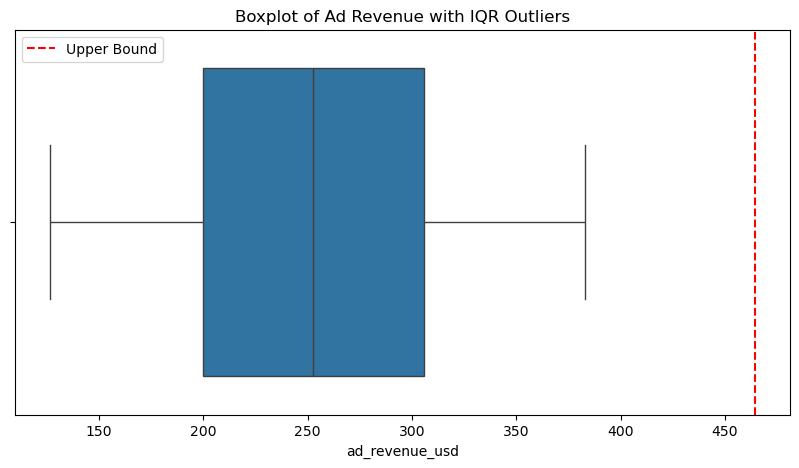

In [64]:
Q1 = youtube_df['ad_revenue_usd'].quantile(0.25)
Q3 = youtube_df['ad_revenue_usd'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_iqr = youtube_df[(youtube_df['ad_revenue_usd'] < lower_bound) | (youtube_df['ad_revenue_usd'] > upper_bound)]

print(f"Total number of IQR outliers: {len(outliers_iqr)}")

df_cleaned = youtube_df[(youtube_df['ad_revenue_usd'] >= lower_bound) & (youtube_df['ad_revenue_usd'] <= upper_bound)]

plt.figure(figsize=(10, 5))
sns.boxplot(x=youtube_df['ad_revenue_usd'])
plt.title('Boxplot of Ad Revenue with IQR Outliers')
plt.axvline(upper_bound, color='red', linestyle='--', label='Upper Bound')
plt.legend()
plt.show()

In [65]:
top_1_percent = youtube_df['ad_revenue_usd'].quantile(0.99)
bottom_1_percent = youtube_df['ad_revenue_usd'].quantile(0.01)

relative_outliers = youtube_df[(youtube_df['ad_revenue_usd'] > top_1_percent) | 
                               (youtube_df['ad_revenue_usd'] < bottom_1_percent)]

print(f"Top 1% threshold: ${top_1_percent:.2f}")
print(f"Number of 'relative' outliers: {len(relative_outliers)}")

Top 1% threshold: $363.58
Number of 'relative' outliers: 2448


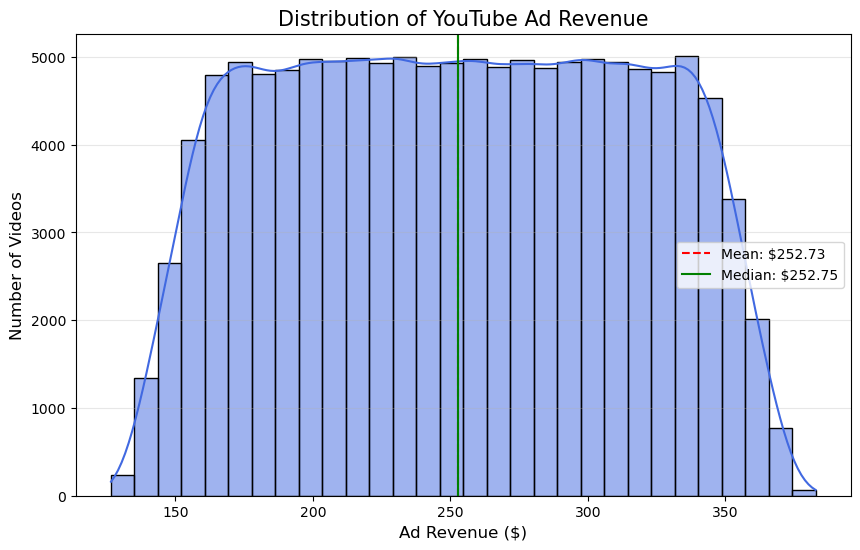

In [66]:
plt.figure(figsize=(10, 6))

sns.histplot(youtube_df['ad_revenue_usd'], kde=True, color='royalblue', bins=30)

plt.axvline(youtube_df['ad_revenue_usd'].mean(), color='red', linestyle='--', label=f'Mean: ${youtube_df["ad_revenue_usd"].mean():.2f}')
plt.axvline(youtube_df['ad_revenue_usd'].median(), color='green', linestyle='-', label=f'Median: ${youtube_df["ad_revenue_usd"].median():.2f}')

plt.title('Distribution of YouTube Ad Revenue', fontsize=15)
plt.xlabel('Ad Revenue ($)', fontsize=12)
plt.ylabel('Number of Videos', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

In [67]:
# Create a list of the categorical columns you want to encode
cols_to_encode = ['category', 'device', 'country']

# Filter the list to only include columns that actually exist in the dataframe
existing_cols = [col for col in cols_to_encode if col in youtube_df.columns]

if existing_cols:
    youtube_df = pd.get_dummies(youtube_df, columns=existing_cols, drop_first=True)
    print(f"Successfully encoded: {existing_cols}")
else:
    print("Columns already encoded or not found.")

# 3. Verify the result
print(youtube_df.head())
print("\nNew Column List:", youtube_df.columns.tolist())

Successfully encoded: ['category', 'device', 'country']
   views  likes  comments  watch_time_minutes  video_length_minutes  \
0   9936   1221       320        26497.214184              2.862137   
1  10017    642       346        15209.747445             23.738069   
2  10097   1979       187        57332.658498             26.200634   
3  10034   1191       242        31334.517771             11.770340   
4   9889   1858       477        15665.666434              6.635854   

   subscribers  ad_revenue_usd  year  month  day  ... category_Music  \
0       228086      203.178237  2024      9   24  ...          False   
1       736015      140.880508  2024      9   22  ...          False   
2       240534      360.134008  2024     11   21  ...          False   
3       434482      224.638261  2025      1   28  ...          False   
4        42030      165.514388  2025      4   28  ...          False   

   category_Tech  device_Mobile  device_TV  device_Tablet  country_CA  \
0          

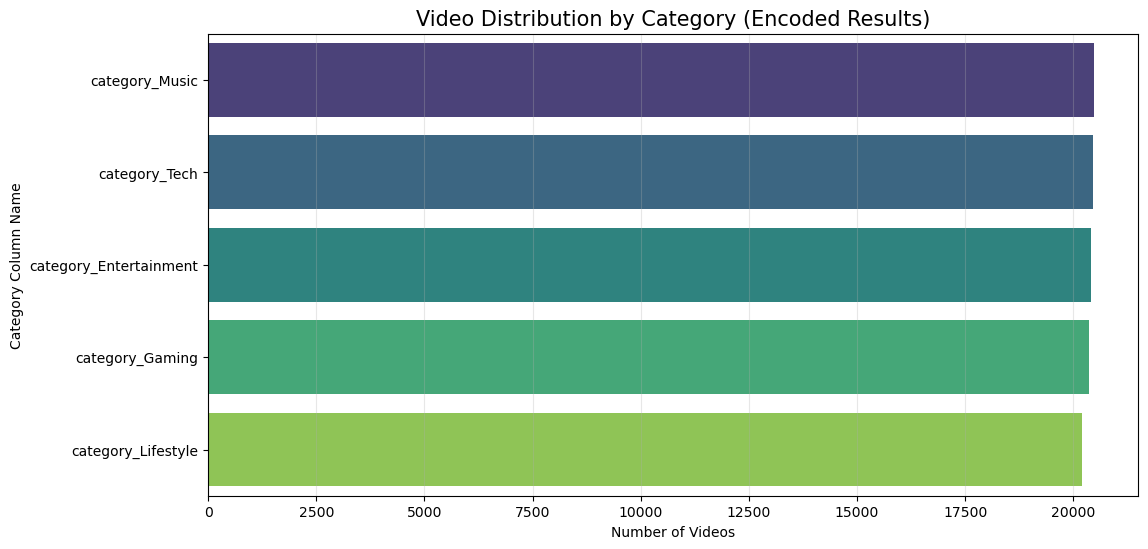

In [68]:
# Identify the new columns created by the encoding
cat_cols = [col for col in youtube_df.columns if 'category_' in col]

# Sum the values (since they are 1s and 0s, the sum is the count)
category_counts = youtube_df[cat_cols].sum().sort_values(ascending=False)

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(x=category_counts.values, y=category_counts.index, palette='viridis')
plt.title('Video Distribution by Category (Encoded Results)', fontsize=15)
plt.xlabel('Number of Videos')
plt.ylabel('Category Column Name')
plt.grid(axis='x', alpha=0.3)
plt.show()

In [69]:
# 1. Get all dummy columns
dummy_cols = [col for col in youtube_df.columns if any(x in col for x in ['category_', 'device_', 'country_'])]

# 2. Calculate correlations directly (this was already correct)
correlations = youtube_df[dummy_cols].corrwith(youtube_df['ad_revenue_usd'])

# 3. Get the top 15 features (sorted ascending for the horizontal bar chart)
top_corrs = correlations.sort_values(ascending=True).tail(15)
print(top_corrs)

category_Lifestyle       -0.006218
device_TV                -0.004104
category_Entertainment   -0.002032
country_UK               -0.001978
category_Music           -0.001010
country_IN               -0.000936
country_DE                0.000133
country_CA                0.000656
device_Tablet             0.002592
country_US                0.003489
device_Mobile             0.005109
category_Tech             0.005393
category_Gaming           0.005626
dtype: float64


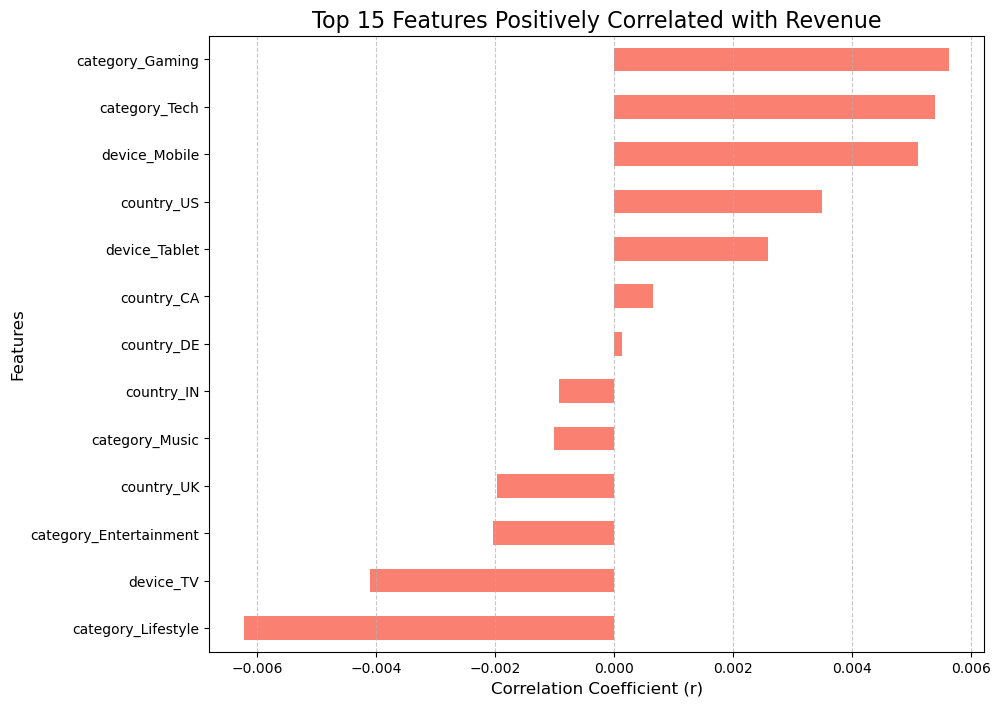

In [70]:
# Create the plot
plt.figure(figsize=(10, 8))
top_corrs.plot(kind='barh', color='salmon')

# Styling
plt.title('Top 15 Features Positively Correlated with Revenue', fontsize=16)
plt.xlabel('Correlation Coefficient (r)', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

['category_Lifestyle', 'category_Gaming', 'category_Tech', 'device_Mobile', 'device_TV', 'country_US', 'device_Tablet', 'category_Entertainment', 'country_UK', 'category_Music']


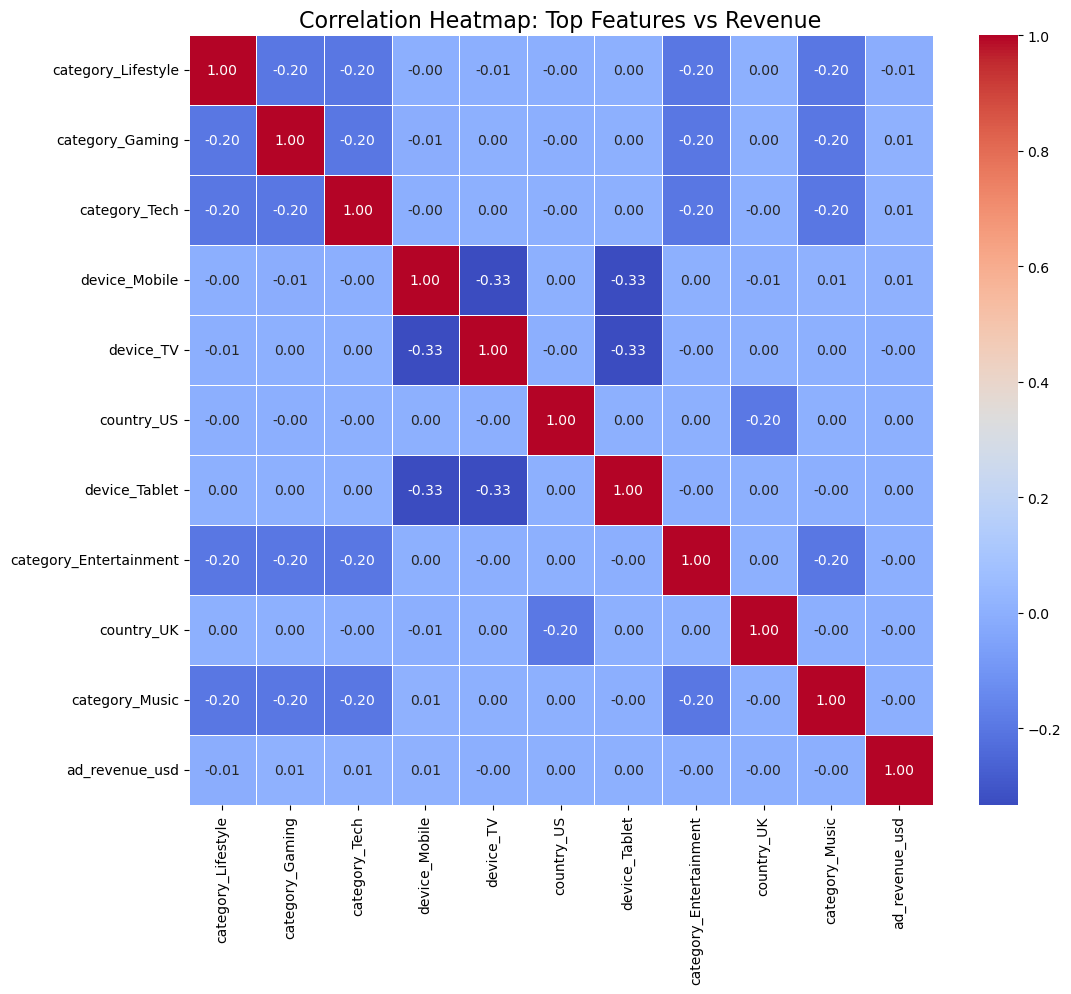

In [71]:
# Identify the top 10 features most correlated with revenue
top_features = correlations.abs().sort_values(ascending=False).head(10).index.tolist()
print(top_features)

# Add the target column to the list
cols_to_plot = top_features + ['ad_revenue_usd']

# Calculate the correlation matrix for ONLY these columns
matrix = youtube_df[cols_to_plot].corr()

# Create the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title('Correlation Heatmap: Top Features vs Revenue', fontsize=16)
plt.show()

In [72]:
model_to_pickle = {
    'ols_model.pkl': ols_model,
    'ridge_model.pkl': ridge_model,
    'lasso_model.pkl': lasso_model,
    'sgd_model.pkl': sgd_model,
    'poly_model.pkl': poly_model,      
    'scaler.pkl': scaler,              
    'poly_transformer.pkl': poly       
}

for pkl_filename, model_obj in model_to_pickle.items():
    with open(pkl_filename, 'wb') as f:
        pickle.dump(model_obj, f)
    print(f"Exported: {pkl_filename}")

Exported: ols_model.pkl
Exported: ridge_model.pkl
Exported: lasso_model.pkl
Exported: sgd_model.pkl
Exported: poly_model.pkl
Exported: scaler.pkl
Exported: poly_transformer.pkl
